In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import ticker
from scipy.integrate import solve_ivp
from numpy.fft import fft, ifft, fftfreq, fftshift, ifftshift
import os
import json


In [2]:
# Global parameter setting
np.random.seed(42)

# smoothness of prior distribution and initial condition
alpha = 1.5+1e-12
beta = 4
zeta = 6

# Fourier truncation for the prior
K_N = 5
# Fourier truncation for rho
rho_N = 20

# Space grid: Periodic [0, 1)
NX = 128            
L = 1.0
x_grid = np.linspace(0.0, L, NX, endpoint=False)
dx = L / NX

# Time grid: Closed [0, T]
NT = 100          
# number of data in the time-space grid
N_TOTAL = (NT + 1) * NX
T_FINAL = 0.1
dt = T_FINAL / NT
t_grid = np.linspace(0.0, T_FINAL, NT + 1)

# Scaling for prior distribution
SCALING_FACTOR = N_TOTAL ** ((alpha + 1 + beta) / (2*(alpha+1) + 2*beta + 1) - 1/2)


In [3]:
# Initial Condition phi(x)
def initial_condition(x, zeta_=None):
    if zeta_ is None:
        zeta_ = zeta
    s = np.zeros_like(x, dtype='float64')

    for k in range(1, rho_N+1):
        '''
        if 1 <= k <= K_N:
            term_cos = 1 * np.cos(2*np.pi*k*x)
            s += term_cos
        else:'''
        weight = 2.0 / (1.0 + 2*np.pi**2*k**2)**(zeta_/2)
        term_cos = np.cos(2*np.pi*k*x)        
        s += weight * term_cos
    phi = s + 1
    phi = phi - np.min(phi) + 1e-4
    mass = np.sum(phi) * dx
    phi /= mass
    
    return phi

def generate_coef_vec_for_prior(K_N, tau, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    k = np.arange(1, K_N+1)  # k = 1..K
    weights = tau * (2.0 / ((1 + k**2) ** ((alpha+1) / 2)))
    # weights = 2 * weights
    cov = np.diag(weights**2)
    
    return rng.multivariate_normal(np.zeros(K_N), cov)
   
# W(x) prior
def prior(x, cos_coeff):
    W = np.zeros_like(x)

    for k in range(1, K_N + 1):
        term_cos = np.cos(2*np.pi*k*x)
        W += cos_coeff[k-1] * term_cos
    return W 

def grad_prior(x, cos_coeff):
    grad_W = np.zeros_like(x)

    for k in range(1, K_N + 1):
        grad_W -= cos_coeff[k-1] * 2*np.pi*k * np.sin(2*np.pi*k*x)
    return grad_W 


In [4]:
def forward_map_full_history_symmetric(cos_coeff, zeta_=None):
    """
    De-aliased pseudo-spectral IMEX Euler for:
        ∂t ρ = ∂xx ρ + ∂x(ρ * (W' * ρ))
    with periodic BC on [0,1).
    - W symmetric => only cos_coeff used.
    """
    if zeta_ is None:
        zeta_ = zeta

    # base wavenumbers
    k_freq = fftfreq(NX, d=dx)
    k_wav  = 2 * np.pi * k_freq
    ik     = 1j * k_wav
    k2     = k_wav**2

    # IMEX diffusion operator (implicit)
    diffusion_operator = 1.0 / (1.0 + dt * k2)

    # build W'_hat in base grid directly in Fourier
    Wprime_x = grad_prior(x_grid, cos_coeff)
    Wprime_hat = fft(Wprime_x)

    # init
    rho = initial_condition(x_grid, zeta_)
    rho_history = np.zeros((NT + 1, NX), dtype=float)
    rho_history[0, :] = rho

    rho_hat = fft(rho)

    for n in range(NT):
        # u = (W' * rho)  (discrete convolution consistent with FFT conventions)
        # NOTE: multiply by dx to approximate integral convolution on [0,1)
        u = np.real(ifft(Wprime_hat * rho_hat)) * dx

        rho_x = np.real(ifft(rho_hat))
        flux = rho_x * u

        # interaction term: ∂x(flux)
        interaction_hat = ik * fft(flux)

        # IMEX Euler update
        rho_hat = (rho_hat + dt * interaction_hat) * diffusion_operator

        rho_next = np.real(ifft(rho_hat))

        rho_next = np.maximum(rho_next, 0.0)
        rho_next /= (np.sum(rho_next) * dx)

        rho_history[n + 1, :] = rho_next
        rho_hat = fft(rho_next)

    return rho_history


Max Absolute Error between Solver and Exact: 6.47e-02


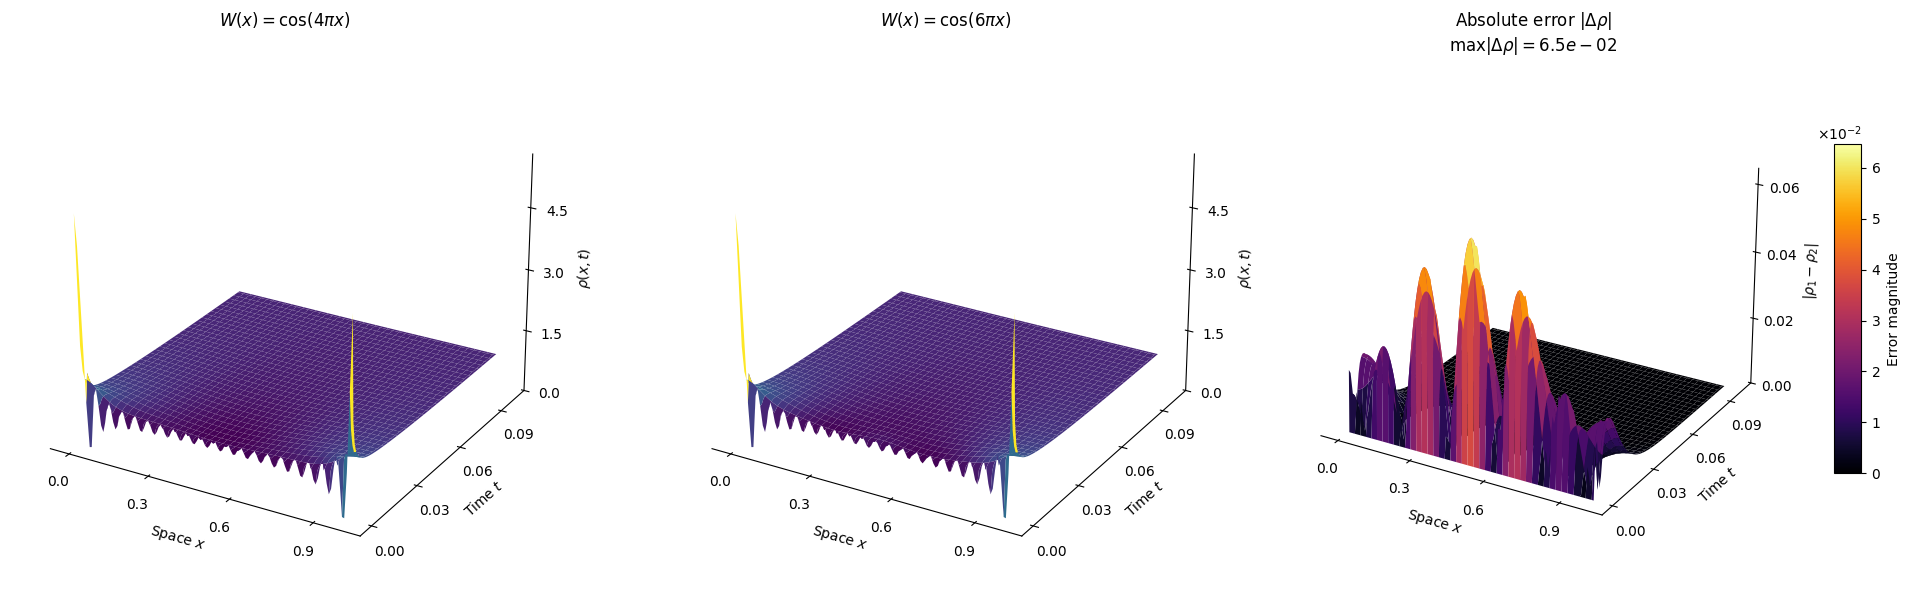

In [5]:
X, T_mesh = np.meshgrid(x_grid, t_grid) 
g1 = np.zeros(K_N)
g2 = np.zeros(K_N)
g1[1] = 1
g2[2] = 1

rho_1 = forward_map_full_history_symmetric(g1,0)
rho_2  = forward_map_full_history_symmetric(g2,0)

error_surface = np.abs(rho_1 - rho_2)
max_error = np.max(error_surface)
print(f"Max Absolute Error between Solver and Exact: {max_error:.2e}")

fig = plt.figure(figsize=(20, 6))

# ---------- common scaling (important for paper) ----------
# Same z range for both rho plots
zmin = 0.0
zmax = float(max(np.max(rho_1), np.max(rho_2))) * 1.05

# Fix error color scale & z range
err_vmin, err_vmax = 0.0, float(max_error)

# Same 3D view for all panels
elev, azim = 25, -60

def style_3d(ax):
    ax.view_init(elev=elev, azim=azim)
    ax.grid(False)
    # transparent panes for cleaner look
    try:
        ax.xaxis.pane.set_alpha(0.0)
        ax.yaxis.pane.set_alpha(0.0)
        ax.zaxis.pane.set_alpha(0.0)
    except Exception:
        pass
    # fewer ticks (optional but helps)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.zaxis.set_major_locator(ticker.MaxNLocator(4))

# --- Subplot 1 ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(
    X, T_mesh, rho_1, cmap='viridis',
    rstride=3, cstride=3, linewidth=0, antialiased=True
)
ax1.set_title(r"$W(x)=\cos(4\pi x)$")
ax1.set_xlabel(r"Space $x$")
ax1.set_ylabel(r"Time $t$")
ax1.set_zlabel(r"$\rho(x,t)$")
ax1.set_zlim(zmin, zmax)
style_3d(ax1)

# --- Subplot 2 ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(
    X, T_mesh, rho_2, cmap='viridis',
    rstride=3, cstride=3, linewidth=0, antialiased=True
)
ax2.set_title(r"$W(x)=\cos(6\pi x)$")  
ax2.set_xlabel(r"Space $x$")
ax2.set_ylabel(r"Time $t$")
ax2.set_zlabel(r"$\rho(x,t)$")
ax2.set_zlim(zmin, zmax)
style_3d(ax2)

# --- Subplot 3: Error ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(
    X, T_mesh, error_surface, cmap='inferno',
    vmin=err_vmin, vmax=err_vmax,
    rstride=3, cstride=3, linewidth=0, antialiased=True
)
ax3.set_title(rf"Absolute error $|\Delta\rho|$" + "\n" + rf"$\max|\Delta\rho|={max_error:.1e}$")
ax3.set_xlabel(r"Space $x$")
ax3.set_ylabel(r"Time $t$")
ax3.set_zlabel(r"$|\rho_1-\rho_2|$")
ax3.set_zlim(err_vmin, err_vmax if err_vmax > 0 else 1.0)
style_3d(ax3)

# Colorbar for error (clean formatting)
cbar = fig.colorbar(surf3, ax=ax3, shrink=0.6, aspect=12, pad=0.08)
cbar.set_label(r"Error magnitude")
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((-2, 2))
cbar.update_ticks()

plt.tight_layout()
# plt.savefig("mv_compare_3d.pdf", bbox_inches="tight")  # thesis export
plt.show()

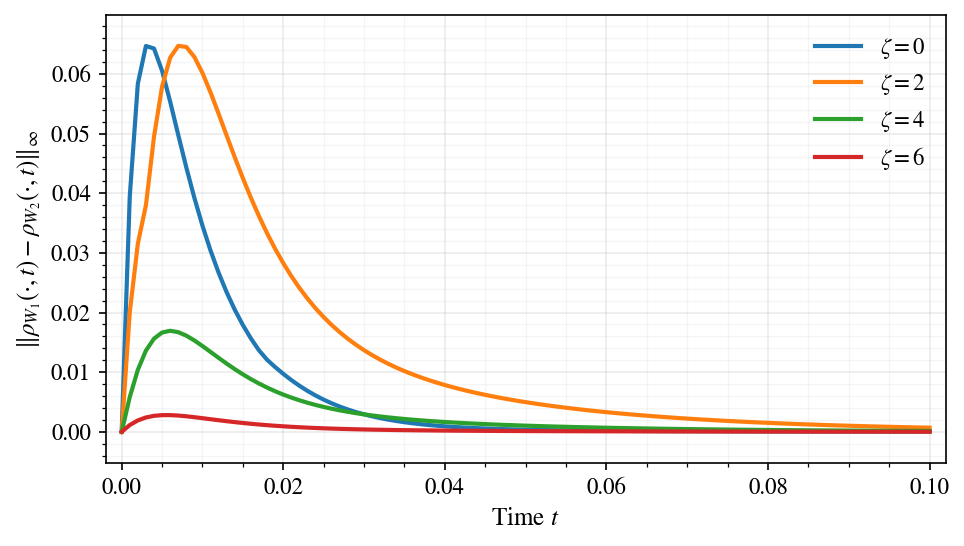

In [6]:
# --- paper style ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})

fig, ax = plt.subplots(figsize=(6.6, 3.8))  

zeta_list = [0, 2, 4, 6]

for zeta_ in zeta_list:
    rho_1 = forward_map_full_history_symmetric(g1, zeta_)
    rho_2 = forward_map_full_history_symmetric(g2, zeta_)
    diff = np.abs(rho_1 - rho_2)
    d_inf = np.max(diff, axis=1)

    ax.plot(t_grid, d_inf, lw=2.0, label=rf"$\zeta={zeta_}$")

ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"$\|\rho_{W_1}(\cdot,t)-\rho_{W_2}(\cdot,t)\|_{\infty}$")

ax.grid(True, which="major", alpha=0.25, linewidth=0.8)
ax.grid(True, which="minor", alpha=0.12, linewidth=0.6)
ax.minorticks_on()

ax.legend(frameon=False, loc="upper right")

ax.margins(x=0.02, y=0.08)

fig.tight_layout()

plt.show()

In [7]:
# MCMC 
# Calculate the log likelihood for MCMC
def log_likelihood(g, Y_obs_full, noise, zeta_=None):
    if zeta_ is None:
        zeta_ = zeta
    rho_pred_history = forward_map_full_history_symmetric(g, zeta_)
    diff = Y_obs_full.ravel() - rho_pred_history.ravel()
    sse = np.sum(diff**2)
    return (-1/(2*noise**2)) * sse

def pCN_MCMC(N_SAMPLES, g_true, noise=0.1, delta=0.1, tau=2.0, seed=None, zeta_=None):
    if zeta_ is None:
        zeta_ = zeta
    ss = np.random.SeedSequence(seed)
    child_seeds = ss.spawn(2)
    rng_data = np.random.default_rng(child_seeds[0])
    rng_mcmc = np.random.default_rng(child_seeds[1])

    rho_true_history = forward_map_full_history_symmetric(g_true, zeta_)
    Y_obs_full = rho_true_history + rng_data.normal(0.0, noise, size=rho_true_history.shape)

    chain = np.zeros((N_SAMPLES, K_N))
    accept_count = 0
    g_curr = np.zeros(K_N)
    lp_curr = log_likelihood(g_curr, Y_obs_full, noise, zeta_)
    
    for i in range(N_SAMPLES):
        x_i = generate_coef_vec_for_prior(K_N, tau, rng=rng_mcmc) 
        # x_i = np.random.normal(0, 1, K_N)
        g_next = np.sqrt(1 - delta**2) * g_curr + delta * x_i
        lp_next = log_likelihood(g_next, Y_obs_full, noise, zeta_)
        
        if np.log(rng_mcmc.random()) < (lp_next - lp_curr):
            g_curr = g_next
            lp_curr = lp_next
            accept_count += 1
        chain[i] = g_curr

    print(f"Acceptance Rate: {accept_count/N_SAMPLES:.2%}")

    return chain, Y_obs_full



In [41]:
def visualize_bayesian_results_symmetric(
    x_grid,
    W_true_plot,
    W_mean,
    W_low,
    W_high,
    thinned_chain,          # shape: (n_samples, K_N)  only contain cos coeff
    g_true=None,            # shape: (K_N,)
    ncols=5
):
    """
    Symmetric case: only cosine coefficients.
    - thinned_chain: (n_samples, K_N)
    - g_true optional
    """

    n_samples, num_params = thinned_chain.shape
    ncols = min(ncols, max(1, num_params))
    nrows = int(np.ceil(num_params / ncols))

    param_names = [rf"$\cos$ coefficient $c_{{{i+1}}}$" for i in range(num_params)]

    # W(x) panel + trace plot rows
    total_rows = 2 + nrows

    fig = plt.figure(figsize=(3.6 * ncols, 3.2 * total_rows))
    gs = GridSpec(
        total_rows, ncols, figure=fig,
        height_ratios=[1.4, 1.4] + [1.0] * nrows,
        hspace=0.65, wspace=0.35
    )

    # --- Part 1: W(x) ---
    ax_w = fig.add_subplot(gs[0:2, :])
    ax_w.plot(x_grid, W_true_plot, 'k-', lw=3, label=r'Ground truth $W_0(x)$')
    ax_w.fill_between(
        x_grid, W_low, W_high,
        color='cornflowerblue', alpha=0.20,
        label=r'95\% pointwise credible band'
    )
    ax_w.plot(x_grid, W_mean, 'b--', lw=2, label='Posterior mean')

    ax_w.set_xlabel(r"Space $x$", fontsize=12)
    ax_w.set_ylabel(r"$W(x)$", fontsize=12)
    ax_w.grid(True, linestyle='--', alpha=0.6)
    ax_w.legend(loc='upper right', frameon=True)

    # --- Part 2: Trace plots ---
    trace_row0 = 2
    for i in range(num_params):
        r = i // ncols
        c = i % ncols
        ax_t = fig.add_subplot(gs[trace_row0 + r, c])

        ax_t.plot(thinned_chain[:, i], lw=0.7, color='firebrick', alpha=0.85)

        if g_true is not None:
            ax_t.axhline(g_true[i], color='crimson', ls='--', lw=1.2)

        ax_t.set_title(param_names[i], fontsize=10, pad=4)
        ax_t.grid(True, alpha=0.3)
        ax_t.tick_params(axis='both', labelsize=8)

        if r == nrows - 1:
            ax_t.set_xlabel("Iteration", fontsize=9)

        if c == 0:
            ax_t.set_ylabel("Value", fontsize=9)

    # turn off unused panels
    for j in range(num_params, nrows * ncols):
        r = j // ncols
        c = j % ncols
        ax_empty = fig.add_subplot(gs[trace_row0 + r, c])
        ax_empty.axis("off")

    plt.show()

Acceptance Rate: 28.34%


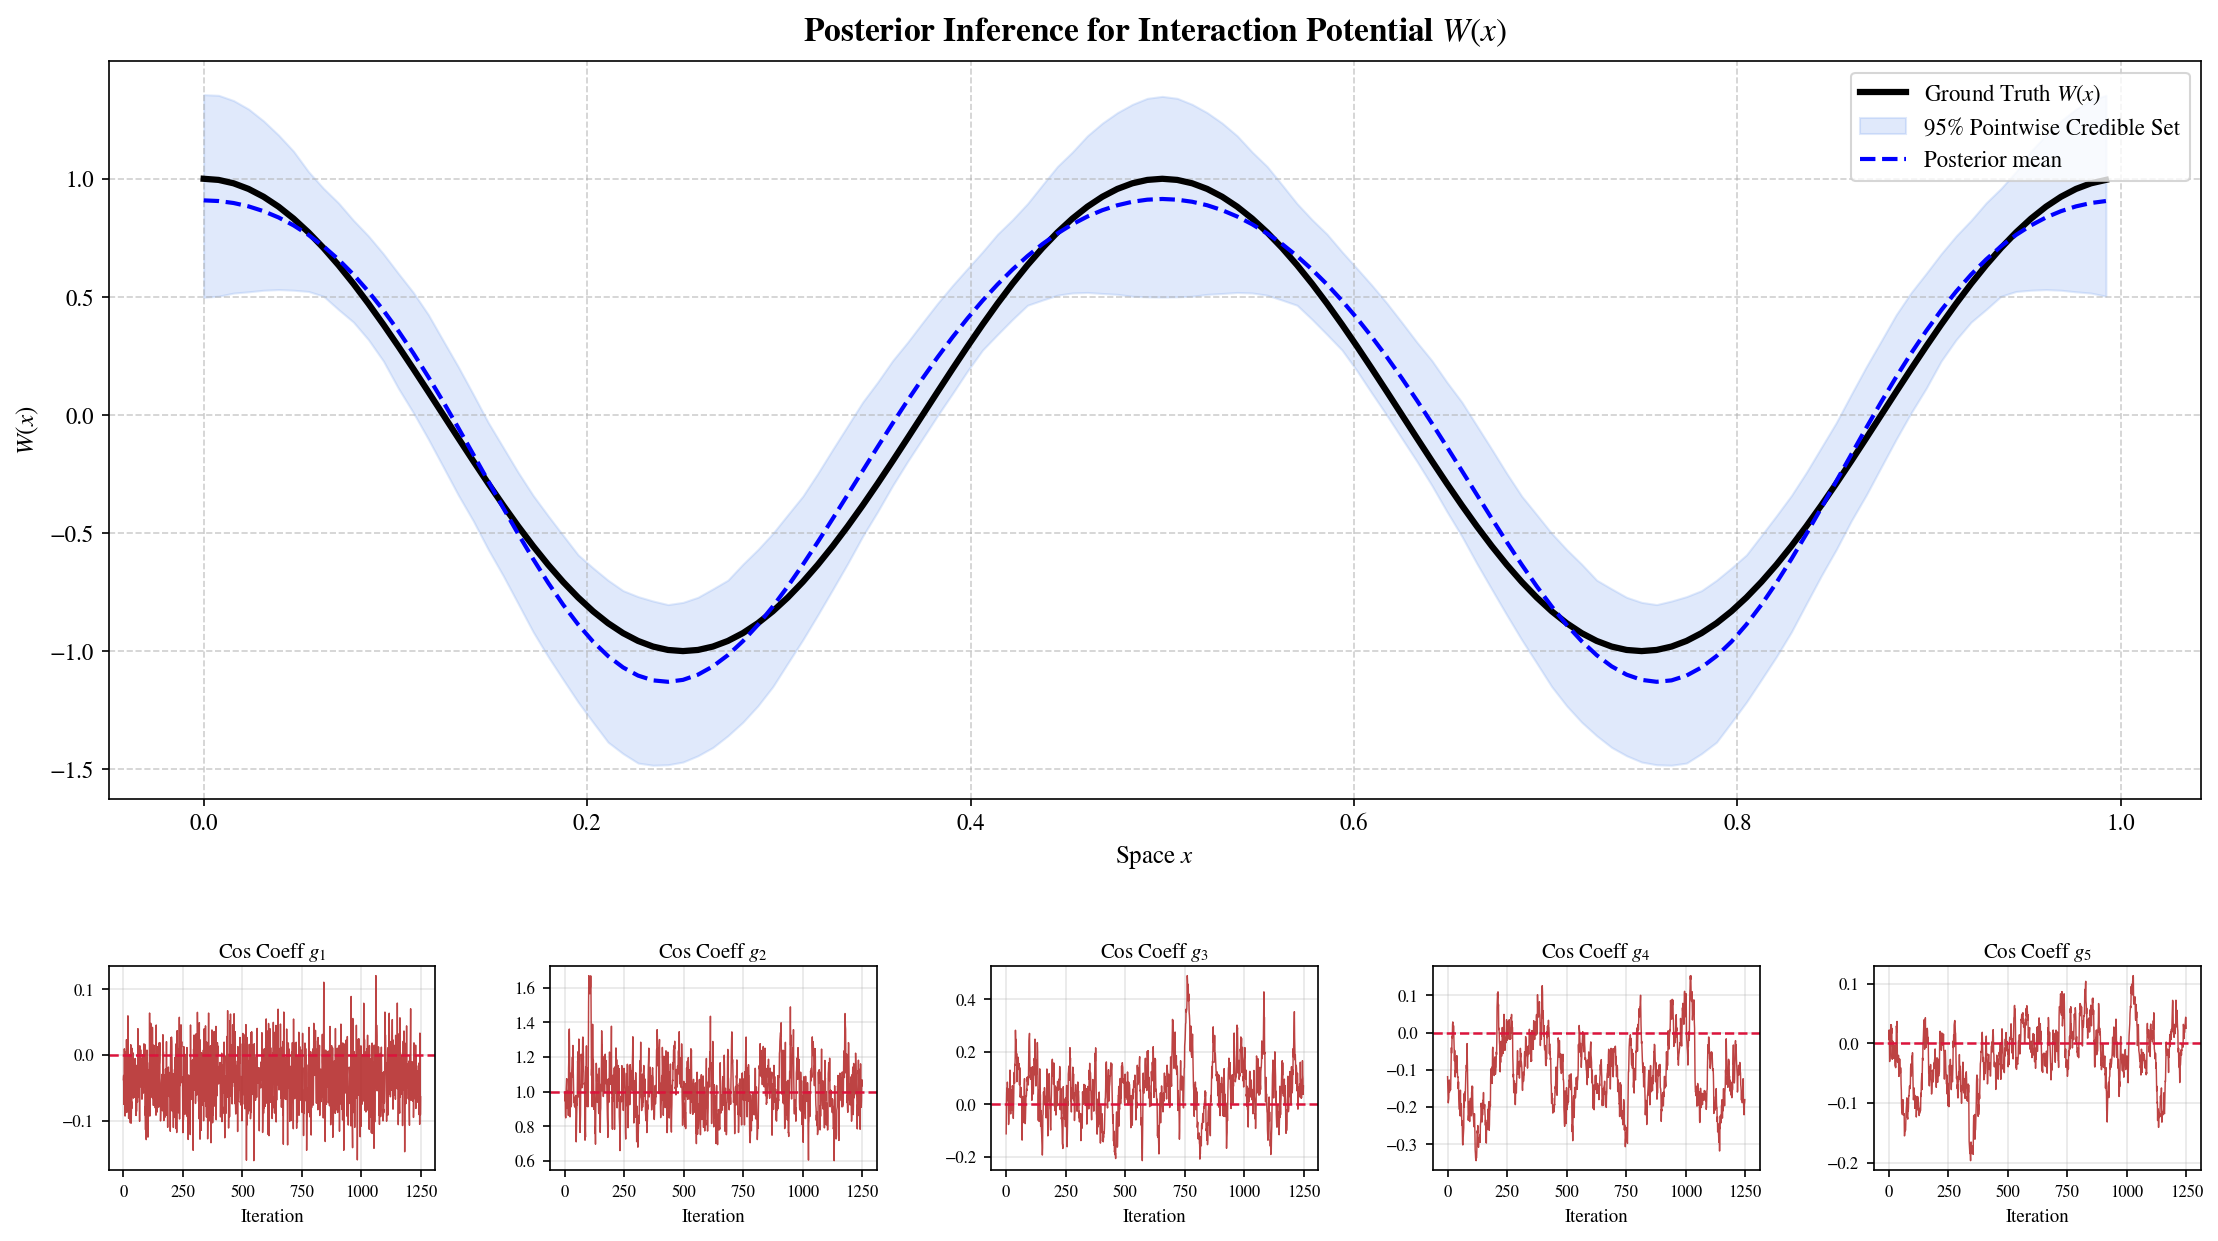

In [ ]:
N_SAMPLES = 50000
burn_in = N_SAMPLES // 2
# Generate Synthetic Data (Y_i, X_i)
g_true = np.zeros(K_N)
g_true[1] = 1

# Visualization 
chain, Y_obs_full = pCN_MCMC(N_SAMPLES, g_true, seed=42, zeta_=0)
final_chain = chain[burn_in:]
thinned_chain = final_chain[::20]

# --- Reconstruction ---
W_ensemble = np.zeros((len(thinned_chain), NX))
for i, g_sample in enumerate(thinned_chain):
    W_ensemble[i, :] = prior(x_grid, g_sample)

# Next we plot the 95% credible set for W(x)
W_mean = np.mean(W_ensemble, axis=0)
# W_std = np.std(W_ensemble, axis=0)
W_true_plot = prior(x_grid, g_true)
# W_median = np.quantile(W_ensemble, 0.5, axis=0)
W_low = np.quantile(W_ensemble, 0.025, axis=0)
W_high = np.quantile(W_ensemble, 0.975, axis=0)



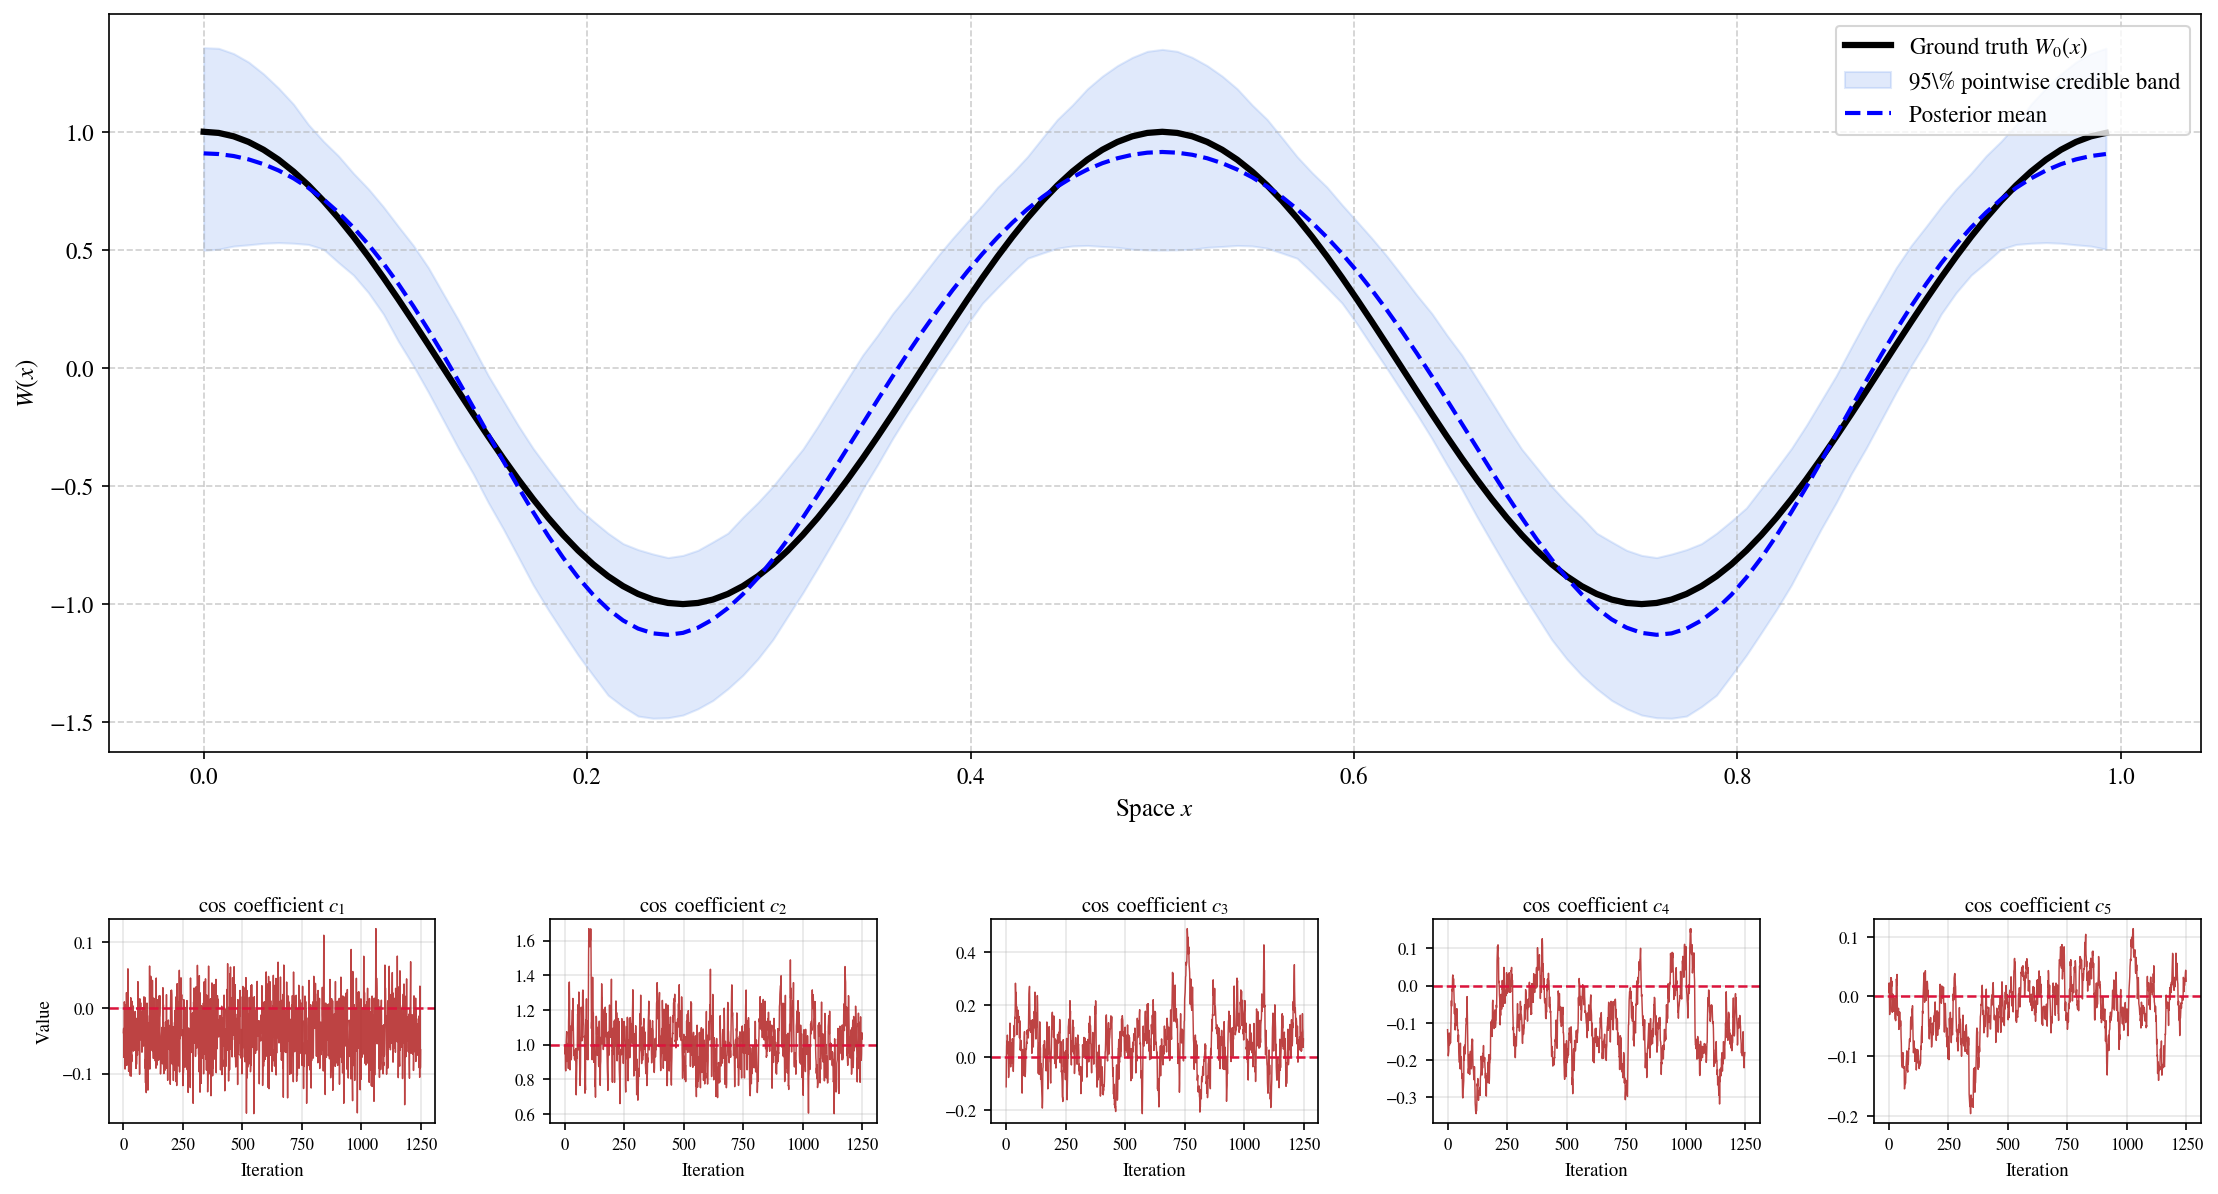

In [42]:
# Execute the visualization
visualize_bayesian_results_symmetric(
    x_grid=x_grid,
    W_true_plot=W_true_plot,
    W_mean=W_mean,
    W_low=W_low,
    W_high=W_high,
    thinned_chain=thinned_chain,
    g_true=g_true,     
    ncols=5
)

In [37]:
def plot_error_surface_only_compact(x_grid, t_grid, rho_true, rho_post, elev=25, azim=-60):
    error_surface = np.abs(rho_true - rho_post)
    max_error = np.max(error_surface)

    X, T_mesh = np.meshgrid(x_grid, t_grid)

    fig = plt.figure(figsize=(5.6, 4.6))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
    X, T_mesh, error_surface,
    cmap='magma',
    rstride=2, cstride=2,
    linewidth=0, antialiased=True
)

    ax.set_xlabel(r"$x$", labelpad=4)
    ax.set_ylabel(r"$t$", labelpad=4)
    ax.set_zlabel(r"$|\Delta \rho|$", labelpad=6)
    ax.set_title(rf"Error surface, $\max |\Delta \rho| = {max_error:.2e}$", fontsize=11, pad=6)

    ax.view_init(elev=elev, azim=azim)
    ax.grid(False)

    try:
        ax.xaxis.pane.set_alpha(0.0)
        ax.yaxis.pane.set_alpha(0.0)
        ax.zaxis.pane.set_alpha(0.0)
    except Exception:
        pass

    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.zaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.tick_params(labelsize=9)

    cbar = fig.colorbar(surf, ax=ax, shrink=0.68, aspect=16, pad=0.06)
    cbar.set_label(r"$|\Delta \rho|$", fontsize=10)
    cbar.ax.tick_params(labelsize=8)
    cbar.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar.formatter.set_powerlimits((-2, 2))
    cbar.update_ticks()

    plt.subplots_adjust(left=0.02, right=0.88, bottom=0.06, top=0.90)
    plt.show()

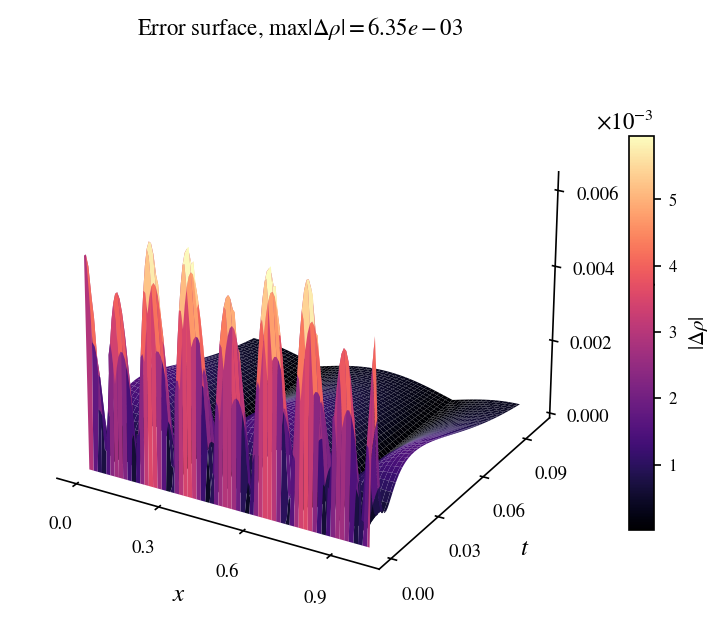

In [38]:
g_post_mean = np.mean(thinned_chain, axis=0)
rho_true = forward_map_full_history_symmetric(g_true, 0)
rho_post = forward_map_full_history_symmetric(g_post_mean, 0)

plot_error_surface_only_compact(x_grid, t_grid, rho_true, rho_post)

In [9]:
def run_100_save_Wstats_style_like_you(
    out_name="W_stats_100.npz",
    n_datasets=100,
    master_seed=20260303,
    # MCMC
    N_SAMPLES=50000,
    g_true=None,
    noise=0.1,
    delta=0.1,
    tau=2.0,
    zeta_=0,
    # post-process
    burn_in=None,
    thin=20,
):
    """
    each dataset:
      chain, Y_obs_full = pCN_MCMC(...)
      thinned_chain = chain[burn_in::thin]
      W_ensemble = [prior(x_grid, g_sample) for g_sample in thinned_chain]
      W_mean, W_low(2.5%), W_high(97.5%)

    save to cwd:
      W_mean_all, W_low_all, W_high_all  shape: (n_datasets, NX)
      seeds, x_grid and meta
    """
    if g_true is None:
        raise ValueError("Please provide g_true (shape: (K_N,)).")
    if burn_in is None:
        burn_in = N_SAMPLES // 2

    print("CWD =", os.getcwd())

    # generate 100 datasets with different seeds
    ss = np.random.SeedSequence(master_seed)
    child = ss.spawn(n_datasets)
    seeds = np.array([int(s.generate_state(1)[0]) for s in child], dtype=np.int64)

    NX_local = len(x_grid)

    W_mean_all = np.zeros((n_datasets, NX_local), dtype=np.float64)
    W_low_all  = np.zeros((n_datasets, NX_local), dtype=np.float64)
    W_high_all = np.zeros((n_datasets, NX_local), dtype=np.float64)

    for j, sd in enumerate(seeds):
        chain, _ = pCN_MCMC(
            N_SAMPLES=N_SAMPLES,
            g_true=g_true,
            noise=noise,
            delta=delta,
            tau=tau,
            seed=int(sd),
            zeta_=zeta_,
        )

        
        final_chain = chain[burn_in:]
        thinned_chain = final_chain[::thin]   # (n_keep, K_N)

        # --- Reconstruction ---
        W_ensemble = np.zeros((len(thinned_chain), NX_local), dtype=np.float64)
        for i, g_sample in enumerate(thinned_chain):
            W_ensemble[i, :] = prior(x_grid, g_sample)

        # posterior mean + 95% credible band
        W_mean = np.mean(W_ensemble, axis=0)
        W_low  = np.quantile(W_ensemble, 0.025, axis=0)
        W_high = np.quantile(W_ensemble, 0.975, axis=0)

        W_mean_all[j] = W_mean
        W_low_all[j]  = W_low
        W_high_all[j] = W_high

    np.savez_compressed(
        out_name,
        x_grid=x_grid,
        W_mean=W_mean_all,
        W_low=W_low_all,
        W_high=W_high_all,
        seeds=seeds,
        # meta
        N_SAMPLES=int(N_SAMPLES),
        burn_in=int(burn_in),
        thin=int(thin),
        noise=float(noise),
        delta=float(delta),
        tau=float(tau),
        zeta=float(zeta_),
    )

    print("Saved to:", os.path.abspath(out_name))
    print("Saved arrays shape:", W_mean_all.shape)
    return W_mean_all, W_low_all, W_high_all, seeds



'''W_mean_all, W_low_all, W_high_all, seeds = run_100_save_Wstats_style_like_you(
     out_name="W_stats_100.npz",
     n_datasets=100,
     master_seed=20260303,
     N_SAMPLES=50000,
     g_true=g_true,
     noise=0.1,
     delta=0.1,
     tau=2.0,
     zeta_=0,
     burn_in=None,
     thin=20,
)'''

'W_mean_all, W_low_all, W_high_all, seeds = run_100_save_Wstats_style_like_you(\n     out_name="W_stats_100.npz",\n     n_datasets=100,\n     master_seed=20260303,\n     N_SAMPLES=50000,\n     g_true=g_true,\n     noise=0.1,\n     delta=0.1,\n     tau=2.0,\n     zeta_=0,\n     burn_in=None,\n     thin=20,\n)'

In [43]:
data = np.load("W_stats_100.npz")
x_grid = data["x_grid"]
W_mean_all = data["W_mean"]   # (100, NX)
W_low_all  = data["W_low"]
W_high_all = data["W_high"]
seeds = data["seeds"]


In [46]:
# 1. max width of credible band
max_diff_credi_band = np.max(W_high_all - W_low_all, axis=1)
max_mean = np.mean(max_diff_credi_band)
max_std = np.std(max_diff_credi_band, ddof=1)

# 2. average length of credible band
average_len_cred_band = dx * np.sum(W_high_all - W_low_all, axis=1)
avg_mean = np.mean(average_len_cred_band)
avg_std = np.std(average_len_cred_band, ddof=1)

# 3. L2 error
W_true_grid = np.cos(4*np.pi*x_grid)
diff = W_mean_all - W_true_grid[None, :]
L2_diff_mean_true = np.sqrt(dx * np.sum(diff**2, axis=1))
L2_mean = np.mean(L2_diff_mean_true)
L2_std = np.std(L2_diff_mean_true, ddof=1)

# 4. L1 error
L1_diff_mean_true = dx * np.sum(np.abs(diff), axis=1)
L1_mean = np.mean(L1_diff_mean_true)
L1_std = np.std(L1_diff_mean_true, ddof=1)

# 5. average UQ coverage
inside = (W_true_grid[None, :] >= W_low_all) & (W_true_grid[None, :] <= W_high_all)
average_UQ = dx * np.sum(inside, axis=1)
UQ_mean = np.mean(average_UQ)
UQ_std = np.std(average_UQ, ddof=1)

print(f"Max width:   {max_mean:.4f} ± {max_std:.4f}")
print(f"Avg length:  {avg_mean:.4f} ± {avg_std:.4f}")
print(f"L2 error:    {L2_mean:.4f} ± {L2_std:.4f}")
print(f"L1 error:    {L1_mean:.4f} ± {L1_std:.4f}")
print(f"Average UQ:  {UQ_mean:.4f} ± {UQ_std:.4f}")

Max width:   0.8267 ± 0.0467
Avg length:  0.5527 ± 0.0236
L2 error:    0.1258 ± 0.0498
L1 error:    0.1070 ± 0.0443
Average UQ:  0.9668 ± 0.0839


In [ ]:
g_true = np.zeros(K_N)
g_true[1] = 1

# zeta = 1
W_mean_all_1, W_low_all_1, W_high_all_1, seeds_1 = run_100_save_Wstats_style_like_you(
    out_name="W_stats_100_zeta1.npz",
    n_datasets=100,
    master_seed=20260310,   # change seed，avoiding the same seed for zeta=0 
    N_SAMPLES=50000,
    g_true=g_true,
    noise=0.1,
    delta=0.1,
    tau=2.0,
    zeta_=1,
    burn_in=None,
    thin=20,
)


CWD = /Users/huangjunding/Desktop/M4R
Acceptance Rate: 4.36%
Acceptance Rate: 4.22%
Acceptance Rate: 4.26%
Acceptance Rate: 4.15%
Acceptance Rate: 4.29%
Acceptance Rate: 4.53%
Acceptance Rate: 4.39%
Acceptance Rate: 4.48%
Acceptance Rate: 4.12%
Acceptance Rate: 4.45%
Acceptance Rate: 4.42%
Acceptance Rate: 4.23%
Acceptance Rate: 4.19%
Acceptance Rate: 4.26%
Acceptance Rate: 4.42%
Acceptance Rate: 4.27%
Acceptance Rate: 4.27%
Acceptance Rate: 4.25%
Acceptance Rate: 4.16%
Acceptance Rate: 4.19%
Acceptance Rate: 4.25%
Acceptance Rate: 4.39%
Acceptance Rate: 4.32%
Acceptance Rate: 4.48%
Acceptance Rate: 4.30%
Acceptance Rate: 4.38%
Acceptance Rate: 4.40%
Acceptance Rate: 4.36%
Acceptance Rate: 4.22%
Acceptance Rate: 4.51%
Acceptance Rate: 4.31%
Acceptance Rate: 4.46%
Acceptance Rate: 4.11%
Acceptance Rate: 4.34%
Acceptance Rate: 4.39%
Acceptance Rate: 4.33%
Acceptance Rate: 4.35%
Acceptance Rate: 4.36%
Acceptance Rate: 4.45%
Acceptance Rate: 4.42%
Acceptance Rate: 4.29%
Acceptance Rate: 4.

In [12]:
g_true = np.zeros(K_N)
g_true[1] = 1

# zeta = 1
W_mean_all_1, W_low_all_1, W_high_all_1, seeds_1 = run_100_save_Wstats_style_like_you(
    out_name="W_stats_100_zeta2.npz",
    n_datasets=100,
    master_seed=20260316,   # change seed，avoiding the same seed for zeta=0 
    N_SAMPLES=50000,
    g_true=g_true,
    noise=0.1,
    delta=0.1, 
    tau=2.0,
    zeta_=2.0,
    burn_in=None,
    thin=20,
)


CWD = /Users/huangjunding/Desktop/M4R
Acceptance Rate: 5.82%
Acceptance Rate: 5.86%
Acceptance Rate: 5.88%
Acceptance Rate: 5.90%
Acceptance Rate: 6.08%
Acceptance Rate: 5.78%
Acceptance Rate: 5.83%
Acceptance Rate: 5.88%
Acceptance Rate: 5.55%
Acceptance Rate: 6.08%
Acceptance Rate: 5.98%
Acceptance Rate: 5.90%
Acceptance Rate: 5.90%
Acceptance Rate: 5.71%
Acceptance Rate: 5.69%
Acceptance Rate: 5.77%
Acceptance Rate: 5.81%
Acceptance Rate: 5.97%
Acceptance Rate: 5.95%
Acceptance Rate: 6.00%
Acceptance Rate: 5.87%
Acceptance Rate: 6.02%
Acceptance Rate: 5.79%
Acceptance Rate: 5.75%
Acceptance Rate: 5.67%
Acceptance Rate: 5.82%
Acceptance Rate: 5.88%
Acceptance Rate: 5.86%
Acceptance Rate: 5.84%
Acceptance Rate: 5.96%
Acceptance Rate: 6.01%
Acceptance Rate: 5.92%
Acceptance Rate: 5.86%
Acceptance Rate: 6.02%
Acceptance Rate: 6.04%
Acceptance Rate: 5.59%
Acceptance Rate: 5.94%
Acceptance Rate: 5.86%
Acceptance Rate: 5.93%
Acceptance Rate: 6.18%
Acceptance Rate: 6.06%
Acceptance Rate: 5.

In [48]:
data = np.load("W_stats_100_zeta1.npz")
x_grid = data["x_grid"]
W_mean_all = data["W_mean"]   # (100, NX)
W_low_all  = data["W_low"]
W_high_all = data["W_high"]
seeds = data["seeds"]


In [49]:
# 1. max width of credible band
max_diff_credi_band = np.max(W_high_all - W_low_all, axis=1)
max_mean = np.mean(max_diff_credi_band)
max_std = np.std(max_diff_credi_band, ddof=1)

# 2. average length of credible band
average_len_cred_band = dx * np.sum(W_high_all - W_low_all, axis=1)
avg_mean = np.mean(average_len_cred_band)
avg_std = np.std(average_len_cred_band, ddof=1)

# 3. L2 error
W_true_grid = np.cos(4*np.pi*x_grid)
diff = W_mean_all - W_true_grid[None, :]
L2_diff_mean_true = np.sqrt(dx * np.sum(diff**2, axis=1))
L2_mean = np.mean(L2_diff_mean_true)
L2_std = np.std(L2_diff_mean_true, ddof=1)

# 4. L1 error
L1_diff_mean_true = dx * np.sum(np.abs(diff), axis=1)
L1_mean = np.mean(L1_diff_mean_true)
L1_std = np.std(L1_diff_mean_true, ddof=1)

# 5. average UQ coverage
inside = (W_true_grid[None, :] >= W_low_all) & (W_true_grid[None, :] <= W_high_all)
average_UQ = dx * np.sum(inside, axis=1)
UQ_mean = np.mean(average_UQ)
UQ_std = np.std(average_UQ, ddof=1)

print(f"Max width:   {max_mean:.4f} ± {max_std:.4f}")
print(f"Avg length:  {avg_mean:.4f} ± {avg_std:.4f}")
print(f"L2 error:    {L2_mean:.4f} ± {L2_std:.4f}")
print(f"L1 error:    {L1_mean:.4f} ± {L1_std:.4f}")
print(f"Average UQ:  {UQ_mean:.4f} ± {UQ_std:.4f}")

Max width:   0.7921 ± 0.1467
Avg length:  0.3676 ± 0.0364
L2 error:    0.0874 ± 0.0461
L1 error:    0.0706 ± 0.0358
Average UQ:  0.9586 ± 0.1032


In [51]:
data = np.load("W_stats_100_zeta2.npz")
x_grid = data["x_grid"]
W_mean_all = data["W_mean"]   # (100, NX)
W_low_all  = data["W_low"]
W_high_all = data["W_high"]
seeds = data["seeds"]


In [52]:
# 1. max width of credible band
max_diff_credi_band = np.max(W_high_all - W_low_all, axis=1)
max_mean = np.mean(max_diff_credi_band)
max_std = np.std(max_diff_credi_band, ddof=1)

# 2. average length of credible band
average_len_cred_band = dx * np.sum(W_high_all - W_low_all, axis=1)
avg_mean = np.mean(average_len_cred_band)
avg_std = np.std(average_len_cred_band, ddof=1)

# 3. L2 error
W_true_grid = np.cos(4*np.pi*x_grid)
diff = W_mean_all - W_true_grid[None, :]
L2_diff_mean_true = np.sqrt(dx * np.sum(diff**2, axis=1))
L2_mean = np.mean(L2_diff_mean_true)
L2_std = np.std(L2_diff_mean_true, ddof=1)

# 4. L1 error
L1_diff_mean_true = dx * np.sum(np.abs(diff), axis=1)
L1_mean = np.mean(L1_diff_mean_true)
L1_std = np.std(L1_diff_mean_true, ddof=1)

# 5. average UQ coverage
inside = (W_true_grid[None, :] >= W_low_all) & (W_true_grid[None, :] <= W_high_all)
average_UQ = dx * np.sum(inside, axis=1)
UQ_mean = np.mean(average_UQ)
UQ_std = np.std(average_UQ, ddof=1)

print(f"Max width:   {max_mean:.4f} ± {max_std:.4f}")
print(f"Avg length:  {avg_mean:.4f} ± {avg_std:.4f}")
print(f"L2 error:    {L2_mean:.4f} ± {L2_std:.4f}")
print(f"L1 error:    {L1_mean:.4f} ± {L1_std:.4f}")
print(f"Average UQ:  {UQ_mean:.4f} ± {UQ_std:.4f}")

Max width:   1.0025 ± 0.1841
Avg length:  0.5712 ± 0.0644
L2 error:    0.1140 ± 0.0566
L1 error:    0.0974 ± 0.0493
Average UQ:  0.9732 ± 0.0772
